# Module 1: Dataset Overview

## Objective

The objective of this module is to gain a comprehensive understanding of the heart disease dataset before performing detailed exploratory analysis.

This includes examining the dataset structure, assessing data quality, reviewing summary statistics, and understanding the target variable. These initial analyses provide the foundation for subsequent preprocessing and machine learning tasks.

---

## Tasks Performed

- Dataset Overview
- Data Quality Assessment
- Summary Statistics
- Skewness Analysis
- Target Variable Analysis
- Feature Categorization

In [12]:
# ==========================================================
# Step 1: Import Required Libraries
# ==========================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

# Create images folder automatically
os.makedirs("../images", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [13]:
# ==========================================================
# Step 2: Load Cleaned Dataset
# ==========================================================

df = pd.read_csv("../data/processed/cardio_data_cleaned.csv")

print("Dataset Loaded Successfully!")

display(df.head())

Dataset Loaded Successfully!


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category
0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1
1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2
2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1
3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2
4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal


In [14]:
# ==========================================================
# Step 3: Dataset Overview
# ==========================================================

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names")

display(df.columns.tolist())

print("\nData Types")

display(df.dtypes)

print("\nDataset Information")

df.info()

DATASET OVERVIEW
Rows    : 68205
Columns : 14

Column Names


['gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio',
 'age_years',
 'bmi',
 'bp_category']


Data Types


gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
age_years        int64
bmi            float64
bp_category     object
dtype: object


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68205 entries, 0 to 68204
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   gender       68205 non-null  int64  
 1   height       68205 non-null  int64  
 2   weight       68205 non-null  float64
 3   ap_hi        68205 non-null  int64  
 4   ap_lo        68205 non-null  int64  
 5   cholesterol  68205 non-null  int64  
 6   gluc         68205 non-null  int64  
 7   smoke        68205 non-null  int64  
 8   alco         68205 non-null  int64  
 9   active       68205 non-null  int64  
 10  cardio       68205 non-null  int64  
 11  age_years    68205 non-null  int64  
 12  bmi          68205 non-null  float64
 13  bp_category  68205 non-null  object 
dtypes: float64(2), int64(11), object(1)
memory usage: 7.3+ MB


## Observation

The dataset overview provides an understanding of the structure of the clinical dataset.

### Key Findings

- The dataset consists of patient clinical records used for heart disease prediction.
- Each row represents one patient.
- Each column represents one clinical feature.
- The target variable is **cardio**, indicating whether the patient has cardiovascular disease.
- The dataset has already been cleaned and is suitable for exploratory analysis.

In [15]:
# ==========================================================
# Step 4: Data Quality Report
# ==========================================================

missing_values = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()

numerical_features = [
    "age_years",
    "height",
    "weight",
    "bmi",
    "ap_hi",
    "ap_lo"
]

categorical_features = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

quality_report = pd.DataFrame({
    "Metric": [
        "Number of Records",
        "Number of Features",
        "Missing Values",
        "Duplicate Rows",
        "Numerical Features",
        "Categorical Features",
        "Target Variable"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        missing_values,
        duplicate_rows,
        len(numerical_features),
        len(categorical_features),
        "cardio"
    ]
})

display(quality_report)

,Metric,Value
0,Number of Records,68205
1,Number of Features,14
2,Missing Values,0
3,Duplicate Rows,3206
4,Numerical Features,6
5,Categorical Features,6
6,Target Variable,cardio


## Observation

The data quality report summarizes the overall condition of the dataset.

### Findings

- The dataset contains no missing values.
- Duplicate rows were identified after removing the unique identifier (`id`). These records may represent different patients with identical clinical measurements and were therefore retained.
- The dataset contains both numerical and categorical features suitable for further analysis.

In [16]:
# ==========================================================
# Step 5: Summary Statistics
# ==========================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
gender,68205.0,1.348625,0.476539,1.000000,1.000000,1.000000,2.000000,2.000000
height,68205.0,164.372861,8.176756,55.000000,159.000000,165.000000,170.000000,250.000000
weight,68205.0,74.100688,14.288862,11.000000,65.000000,72.000000,82.000000,200.000000
ap_hi,68205.0,126.434924,15.961685,90.000000,120.000000,120.000000,140.000000,180.000000
ap_lo,68205.0,81.263925,9.143985,60.000000,80.000000,80.000000,90.000000,120.000000
cholesterol,68205.0,1.363243,0.678080,1.000000,1.000000,1.000000,1.000000,3.000000
gluc,68205.0,1.225174,0.571288,1.000000,1.000000,1.000000,1.000000,3.000000
smoke,68205.0,0.087662,0.282805,0.000000,0.000000,0.000000,0.000000,1.000000
alco,68205.0,0.053134,0.224302,0.000000,0.000000,0.000000,0.000000,1.000000
active,68205.0,0.803548,0.397317,0.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
# ==========================================================
# Step 6: Skewness Analysis
# ==========================================================

skewness = (
    df[numerical_features]
    .skew()
    .sort_values(ascending=False)
)

display(skewness.to_frame("Skewness"))

,Skewness
bmi,7.818718
weight,1.005810
ap_hi,0.739957
ap_lo,0.238822
age_years,-0.303567
height,-0.611868


In [7]:
# =====================================================
# Step 7: Verify Duplicate Records
# =====================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 3206


## Observation

The statistical summary provides information about the central tendency, variability, and spread of numerical variables.

### Important Observations

- Patients belong mainly to middle-aged and older age groups.
- BMI values vary considerably across the population.
- Blood pressure measurements show wider variation compared to other variables.
- Some numerical variables exhibit positive skewness, indicating the presence of extreme clinical values.

In [18]:
# ==========================================================
# Step 7: Target Variable Distribution
# ==========================================================

target_counts = df["cardio"].value_counts()

display(target_counts)

display(round(df["cardio"].value_counts(normalize=True)*100,2))

cardio
0    34533
1    33672
Name: count, dtype: int64

cardio
0    50.63
1    49.37
Name: proportion, dtype: float64

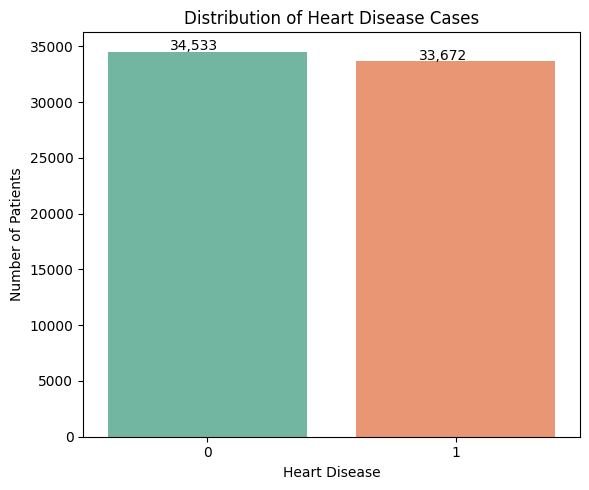

In [19]:
# ==========================================================
# Step 8: Heart Disease Distribution
# ==========================================================

plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="cardio",
    data=df,
    palette="Set2"
)

plt.title("Distribution of Heart Disease Cases")

plt.xlabel("Heart Disease")

plt.ylabel("Number of Patients")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x()+0.25, p.get_height()+100)
    )

plt.tight_layout()

plt.savefig("../images/target_distribution.png", dpi=300)

plt.show()

## Observation

The distribution of the target variable indicates the proportion of patients diagnosed with and without cardiovascular disease.

### Key Findings

- The dataset is relatively balanced.
- A balanced target distribution is beneficial because it reduces model bias toward a particular class.
- This allows the machine learning algorithms to learn meaningful patterns from both classes.

In [20]:
# ==========================================================
# Step 9: Feature Categorization
# ==========================================================

print("Numerical Features\n")

print(numerical_features)

print("\nCategorical Features\n")

print(categorical_features)

print("\nTarget Variable")

print("cardio")

Numerical Features

['age_years', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo']

Categorical Features

['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

Target Variable
cardio


# Module 2: Univariate Analysis

## Objective

The objective of this module is to analyze each feature individually to understand its distribution, frequency, and characteristics.

Univariate analysis helps identify:

- Distribution patterns
- Skewness
- Potential anomalies
- Frequency of categorical variables
- Overall characteristics of each clinical feature

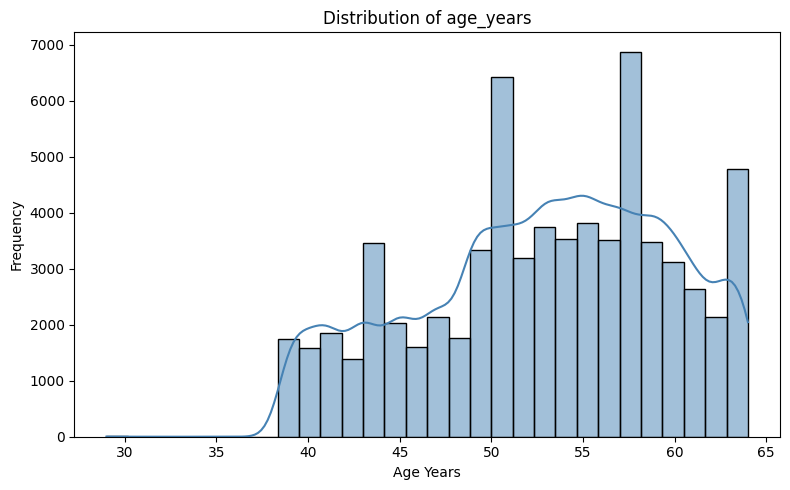

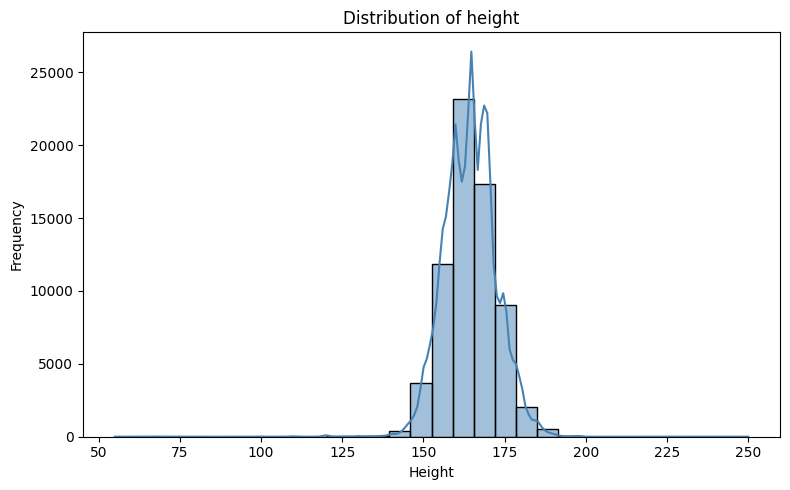

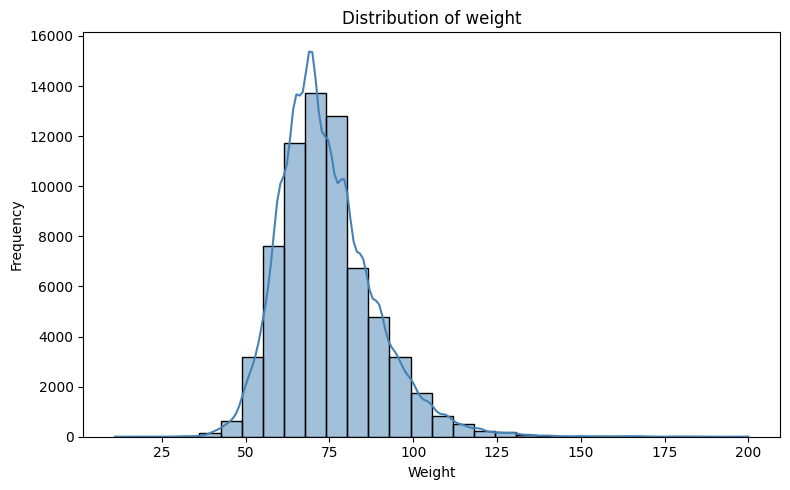

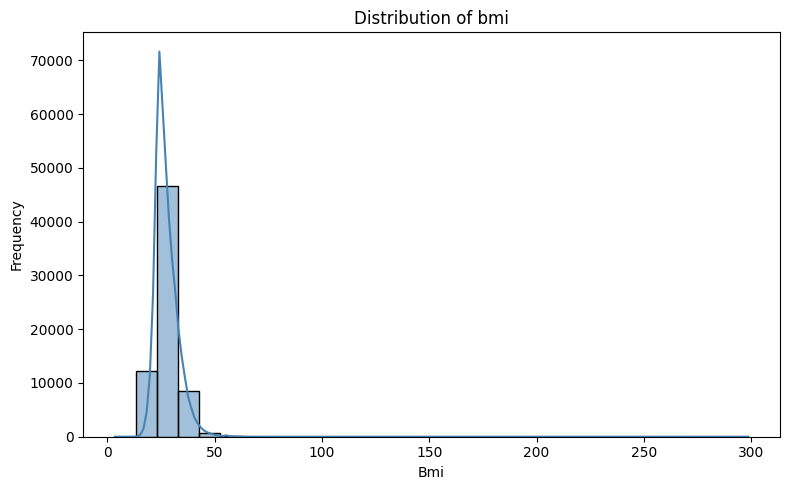

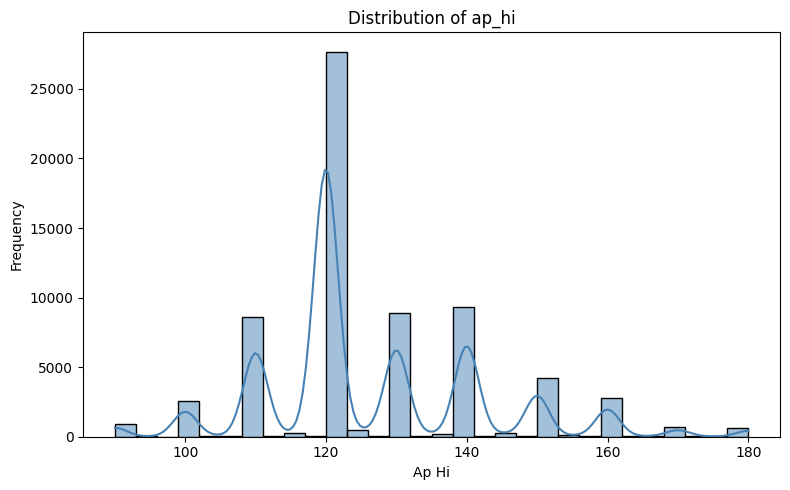

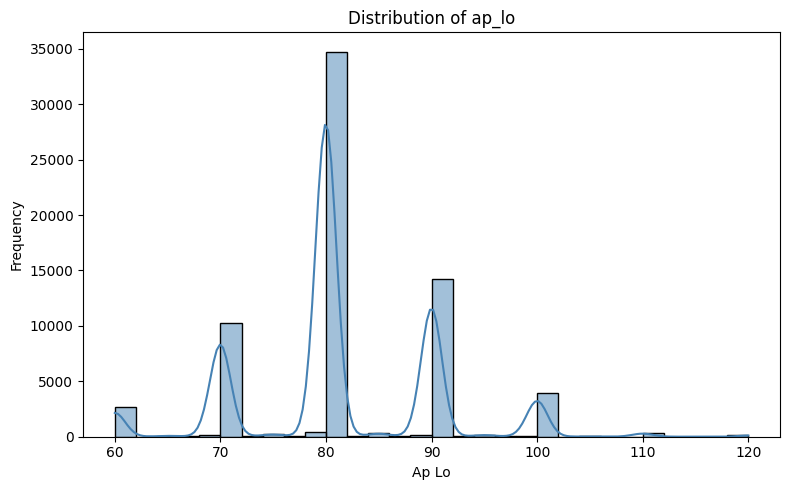

In [21]:
# ==========================================================
# Step 10: Histograms of Numerical Features
# ==========================================================

for feature in numerical_features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        kde=True,
        color="steelblue"
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.savefig(
        f"../images/{feature}_distribution.png",
        dpi=300
    )

    plt.show()

## Observation

Histograms provide an overview of the distribution of numerical variables in the dataset.

### Key Findings

- Age is concentrated among middle-aged and older adults.
- Height follows an approximately normal distribution.
- Weight and BMI exhibit moderate right-skewness.
- Blood pressure measurements show greater variability compared to other clinical features.
- Some extreme values are visible and will be examined during the outlier analysis.

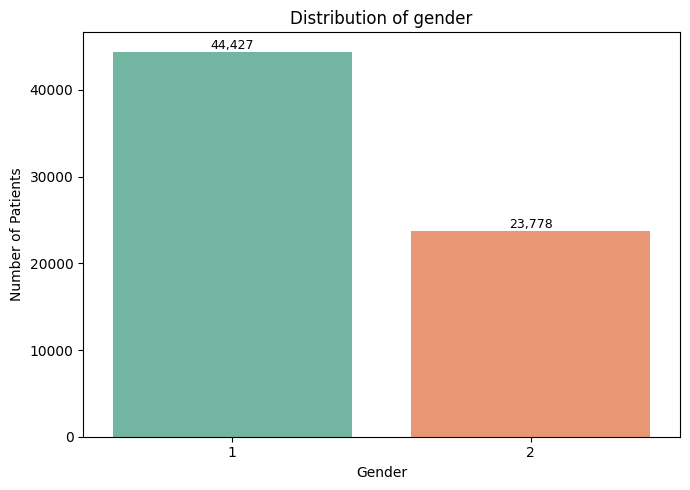

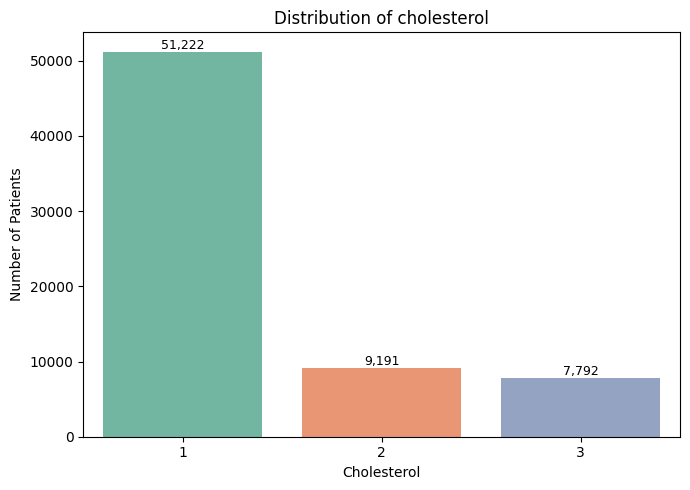

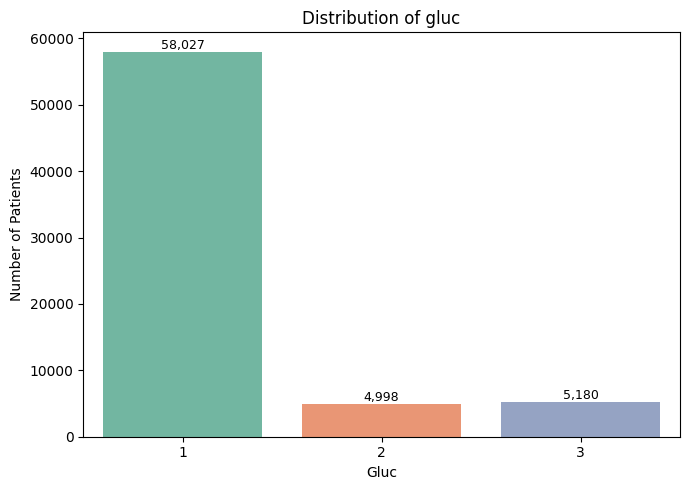

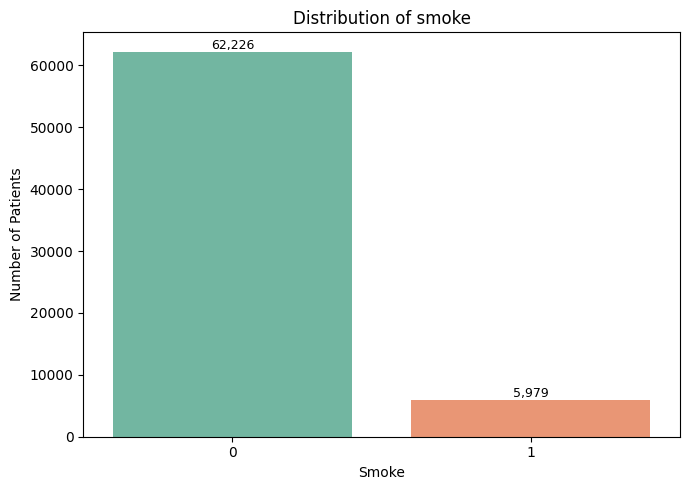

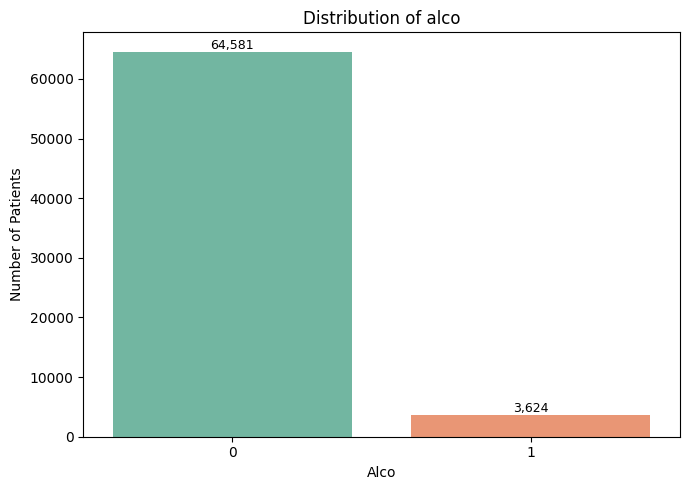

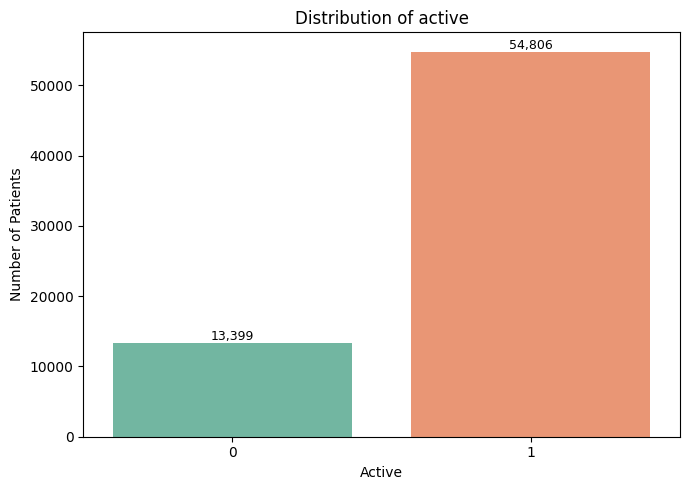

In [22]:
# ==========================================================
# Step 11: Countplots of Categorical Features
# ==========================================================

for feature in categorical_features:

    plt.figure(figsize=(7,5))

    ax = sns.countplot(
        x=feature,
        data=df,
        palette="Set2"
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("Number of Patients")

    # Add value labels
    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height()):,}",
            (p.get_x() + p.get_width()/2., p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()

    plt.savefig(
        f"../images/{feature}_countplot.png",
        dpi=300
    )

    plt.show()

## Observation

The countplots show the frequency distribution of categorical variables.

### Key Findings

- Gender distribution indicates the proportion of patients in each gender category.
- Most patients have normal cholesterol and glucose levels.
- The majority of patients are non-smokers and do not consume alcohol.
- A large proportion of patients are physically active.

In [23]:
# ==========================================================
# Step 12: Percentage Distribution of Categorical Features
# ==========================================================

for feature in categorical_features:

    print("=" * 60)
    print(feature.upper())
    print("=" * 60)

    percentage = (
        df[feature]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    display(percentage)

GENDER


gender
1    65.14
2    34.86
Name: proportion, dtype: float64

CHOLESTEROL


cholesterol
1    75.10
2    13.48
3    11.42
Name: proportion, dtype: float64

GLUC


...

smoke
0    91.23
1     8.77
Name: proportion, dtype: float64

ALCO


alco
0    94.69
1     5.31
Name: proportion, dtype: float64

ACTIVE


active
1    80.35
0    19.65
Name: proportion, dtype: float64

## Observation

The percentage distribution provides a clearer understanding of the proportion of patients within each category.

This analysis helps identify dominant categories and determine whether any categorical feature is significantly imbalanced.

In [24]:
# ==========================================================
# Step 13: Feature Summary Table
# ==========================================================

summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})

display(summary)

,Data Type,Unique Values,Missing Values
gender,int64,2,0
height,int64,106,0
weight,float64,278,0
ap_hi,int64,86,0
ap_lo,int64,58,0
cholesterol,int64,3,0
gluc,int64,3,0
smoke,int64,2,0
alco,int64,2,0
active,int64,2,0


## Observation

The feature summary table provides an overview of each variable, including its data type, number of unique values, and missing value count.

The analysis confirms that the dataset is complete and ready for advanced exploratory analysis.

# Module 3: Outlier & Correlation Analysis

## Objective

The objective of this module is to identify extreme values (outliers), analyze relationships between numerical features, and determine how individual features are associated with the target variable.

This analysis helps in understanding feature importance, identifying multicollinearity, and detecting unusual observations before machine learning model development.

---

## Tasks Performed

- Outlier Analysis
- Correlation Analysis
- Correlation with Target Variable
- Pairwise Relationship Analysis

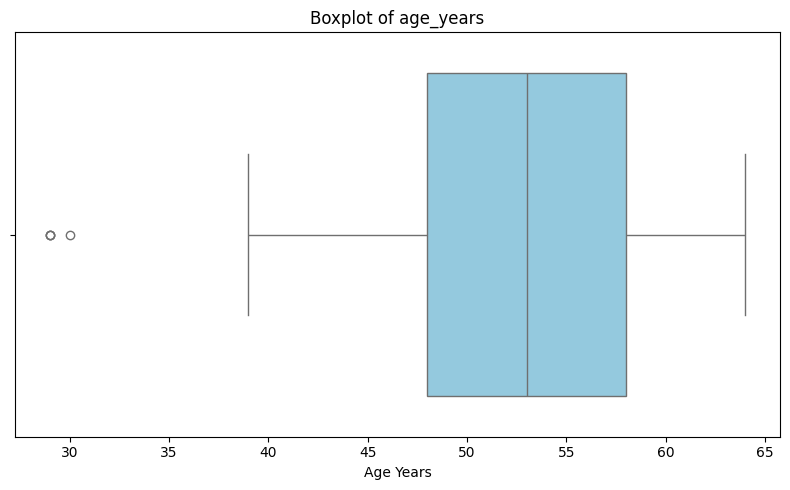

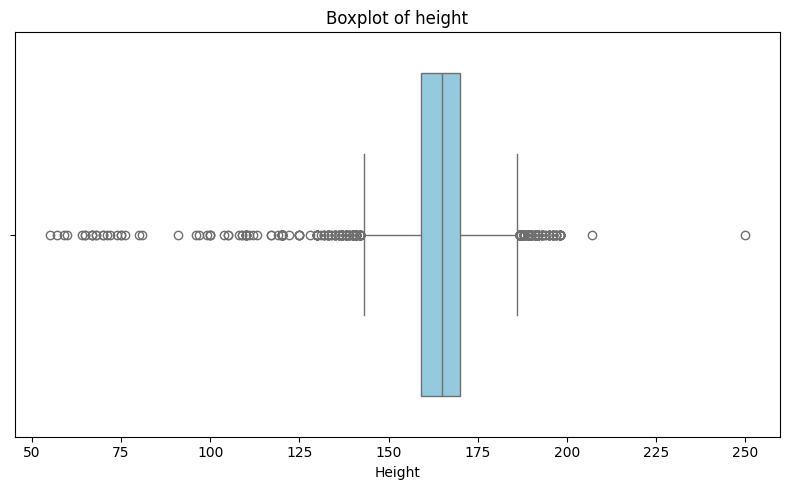

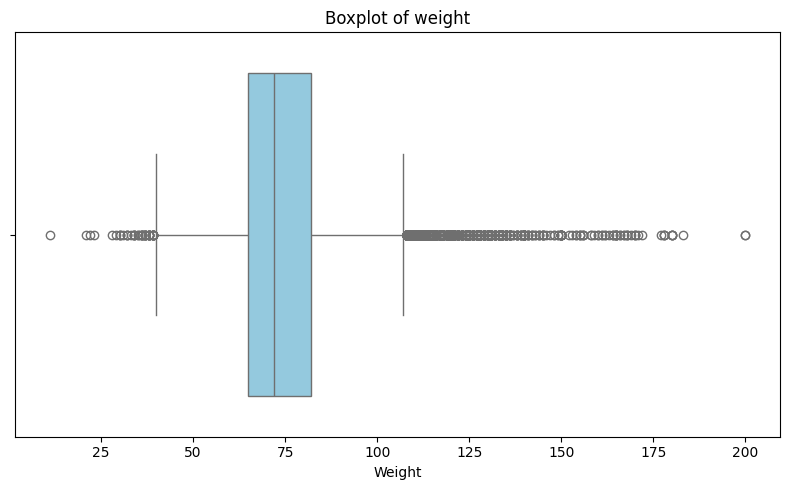

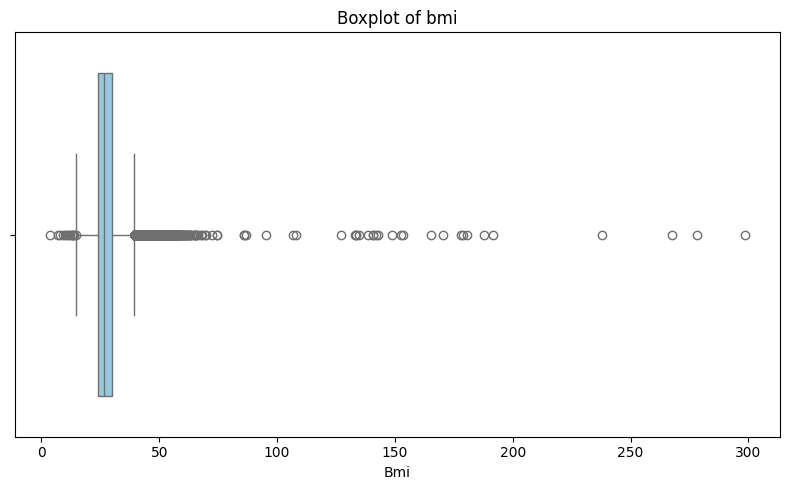

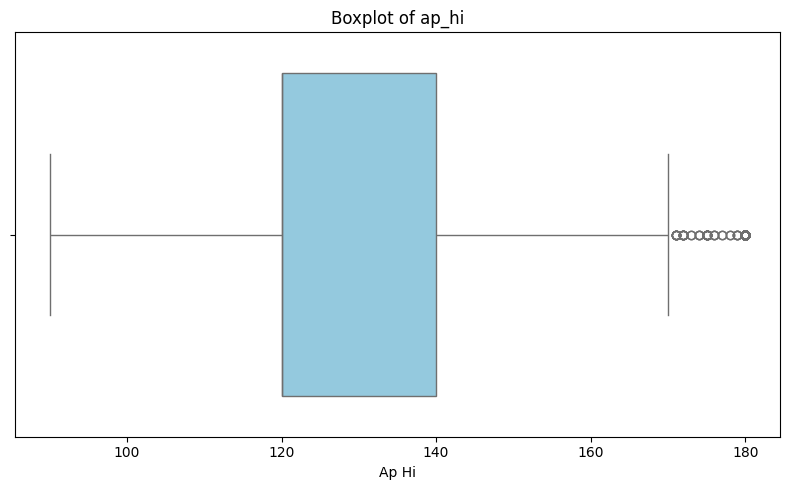

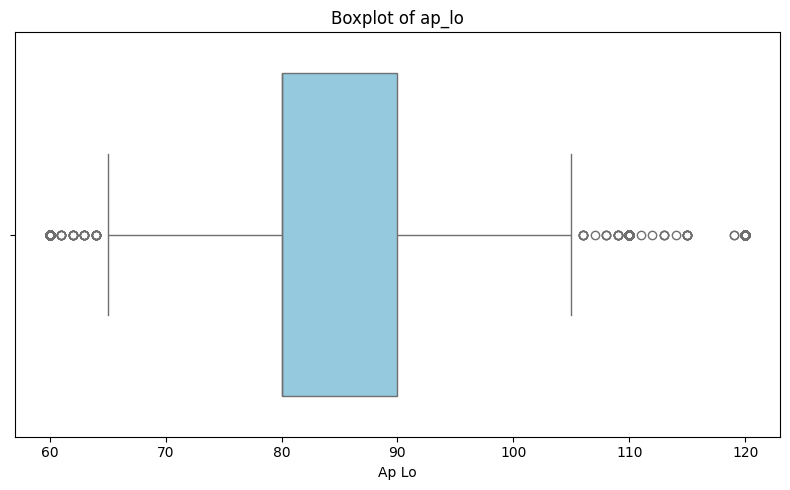

In [25]:
# ==========================================================
# Step 14: Outlier Analysis using Boxplots
# ==========================================================

for feature in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x=df[feature],
        color="skyblue"
    )

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature.replace("_", " ").title())

    plt.tight_layout()

    plt.savefig(
        f"../images/{feature}_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Observation

Boxplots were used to identify potential outliers in the numerical features of the dataset.

### Key Findings

- Height and age show relatively few outliers.
- Weight and BMI contain several extreme observations.
- Systolic (`ap_hi`) and diastolic (`ap_lo`) blood pressure exhibit noticeable outliers, which is expected in clinical datasets due to variations in patient health conditions.
- These observations will be further examined using the Interquartile Range (IQR) method.

In [26]:
# ==========================================================
# Step 15: Detect Outliers using the IQR Method
# ==========================================================

outlier_summary = []

for feature in numerical_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": feature,
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outliers": len(outliers),
        "Percentage (%)": round((len(outliers) / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,Feature,Lower Bound,Upper Bound,Outliers,Percentage (%)
0,age_years,33.00,73.00,4,0.01
1,height,142.50,186.50,502,0.74
2,weight,39.50,107.50,1711,2.51
3,bmi,14.51,39.48,1988,2.91
4,ap_hi,90.00,170.00,648,0.95
5,ap_lo,65.00,105.00,3188,4.67


## Observation

The Interquartile Range (IQR) method was used to quantify the number of outliers present in each numerical feature.

### Key Findings

- Blood pressure and BMI contain the highest number of outliers.
- Most outliers are clinically plausible and may represent patients with abnormal health conditions rather than data entry errors.
- These observations have been retained because removing them could eliminate medically important information and negatively impact model performance.

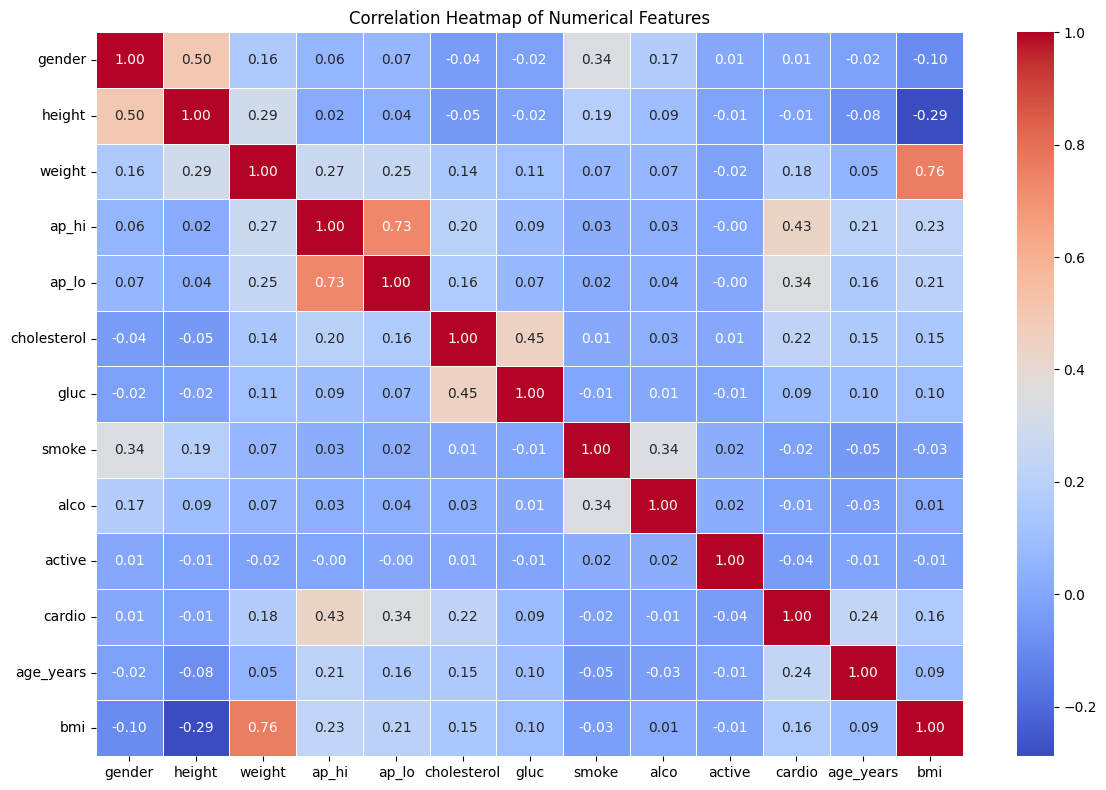

In [27]:
# ==========================================================
# Step 16: Correlation Heatmap
# ==========================================================

plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

The correlation heatmap was used to examine the strength and direction of relationships among numerical features and the target variable.

### Key Findings

- **Weight and BMI** have the strongest positive correlation (**0.76**), which is expected because BMI is calculated using weight and height.
- **Systolic blood pressure (`ap_hi`)** and **diastolic blood pressure (`ap_lo`)** are strongly positively correlated (**0.73**).
- The target variable (**cardio**) shows its strongest positive correlation with:
  - Systolic blood pressure (`ap_hi`) → **0.43**
  - Diastolic blood pressure (`ap_lo`) → **0.34**
  - Age (`age_years`) → **0.24**
  - Cholesterol → **0.22**
- Smoking, alcohol consumption, and physical activity exhibit very weak linear correlations with the target variable.
- No severe multicollinearity was observed among the independent features, except for expected relationships such as **Weight–BMI** and **Systolic–Diastolic Blood Pressure**.

In [28]:
# ==========================================================
# Step 17: Correlation with Target Variable
# ==========================================================

target_corr = (
    correlation_matrix["cardio"]
    .drop("cardio")
    .sort_values(ascending=False)
)

display(target_corr.to_frame(name="Correlation with Cardio"))

,Correlation with Cardio
ap_hi,0.433802
ap_lo,0.342900
age_years,0.238875
cholesterol,0.220778
weight,0.177829
bmi,0.162880
gluc,0.088905
gender,0.006098
alco,-0.009038
height,-0.011276


## Observation

The correlation values indicate how strongly each feature is linearly associated with the presence of cardiovascular disease.

### Key Findings

- Blood pressure measurements (`ap_hi` and `ap_lo`) show the strongest positive relationship with heart disease.
- Age and cholesterol also demonstrate meaningful positive correlations with the target variable.
- Lifestyle-related variables such as smoking, alcohol consumption, and physical activity have relatively weak individual linear relationships with cardiovascular disease.
- These findings suggest that clinical measurements contribute more strongly to heart disease prediction than individual lifestyle indicators.

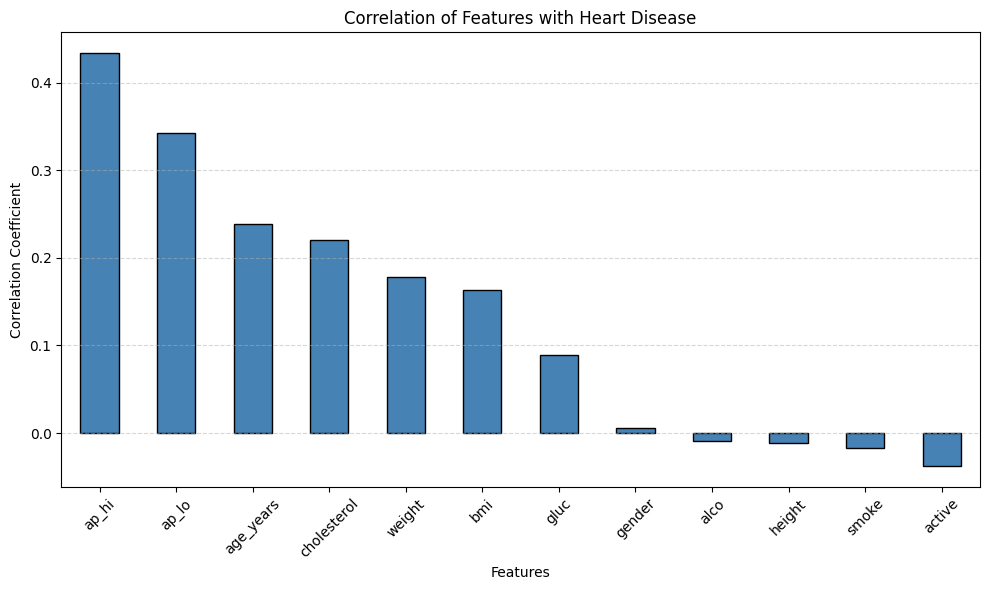

In [29]:
# ==========================================================
# Step 18: Feature Correlation with Heart Disease
# ==========================================================

plt.figure(figsize=(10,6))

target_corr.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Correlation of Features with Heart Disease")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig(
    "../images/feature_target_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

The bar chart provides a clear comparison of the correlation between each feature and the target variable.

### Key Findings

- Blood pressure features have the highest positive correlation with cardiovascular disease.
- Age, cholesterol, and BMI also contribute positively to disease prediction.
- Features such as smoking, alcohol consumption, and physical activity show relatively weak correlations individually.
- Although some variables have low individual correlations, they may still improve prediction performance when combined in machine learning models.

# Module 4: Relationship Between Features and Heart Disease

## Objective

The objective of this module is to investigate how important clinical and lifestyle features are associated with the presence of cardiovascular disease.

By comparing feature distributions across patients with and without heart disease, we can identify important risk factors that influence prediction.

---

## Tasks Performed

- Age vs Heart Disease
- BMI vs Heart Disease
- Blood Pressure vs Heart Disease
- Cholesterol vs Heart Disease
- Glucose vs Heart Disease
- Lifestyle Factors vs Heart Disease

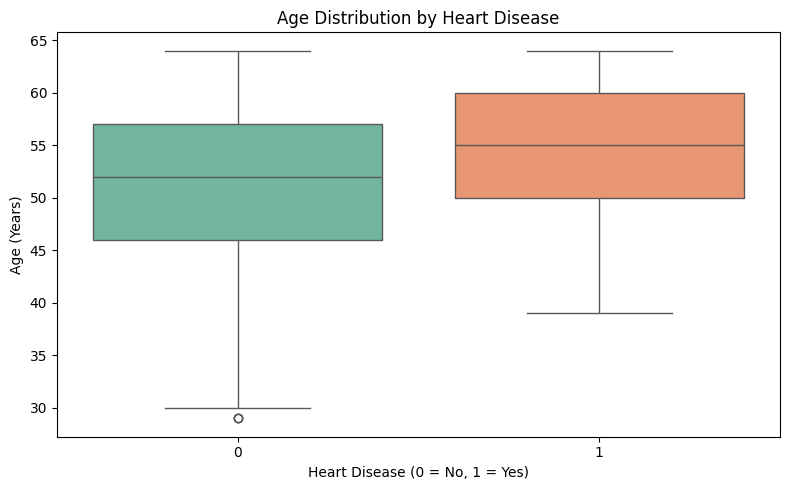

In [30]:
# ==========================================================
# Step 19: Age vs Heart Disease
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x="cardio",
    y="age_years",
    data=df,
    palette="Set2"
)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age (Years)")

plt.tight_layout()

plt.savefig(
    "../images/age_vs_cardio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

Patients diagnosed with cardiovascular disease generally belong to higher age groups.

### Key Findings

- The median age is higher for patients with heart disease.
- Older individuals appear to have a greater risk of cardiovascular disease.
- Age is therefore an important predictor for model development.

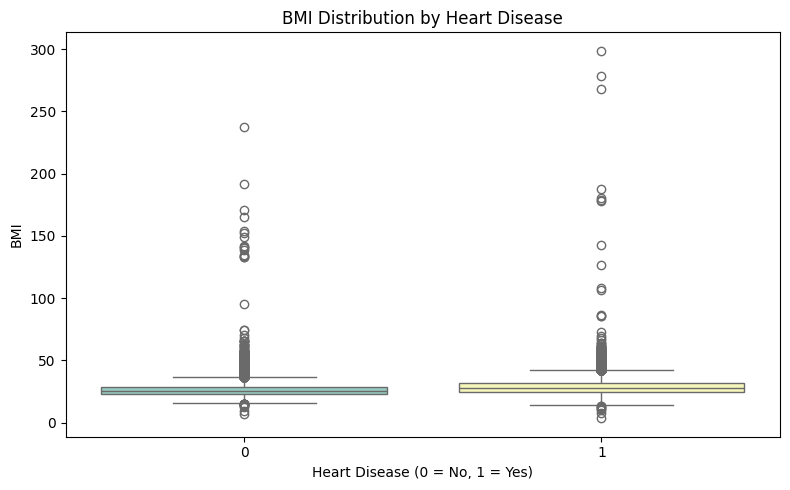

In [31]:
# ==========================================================
# Step 20: BMI vs Heart Disease
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x="cardio",
    y="bmi",
    data=df,
    palette="Set3"
)

plt.title("BMI Distribution by Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("BMI")

plt.tight_layout()

plt.savefig(
    "../images/bmi_vs_cardio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

Patients with cardiovascular disease tend to have slightly higher BMI values.

### Key Findings

- The median BMI is higher for patients with heart disease.
- Higher BMI may increase the risk of cardiovascular disease.
- BMI should be considered an important clinical feature.

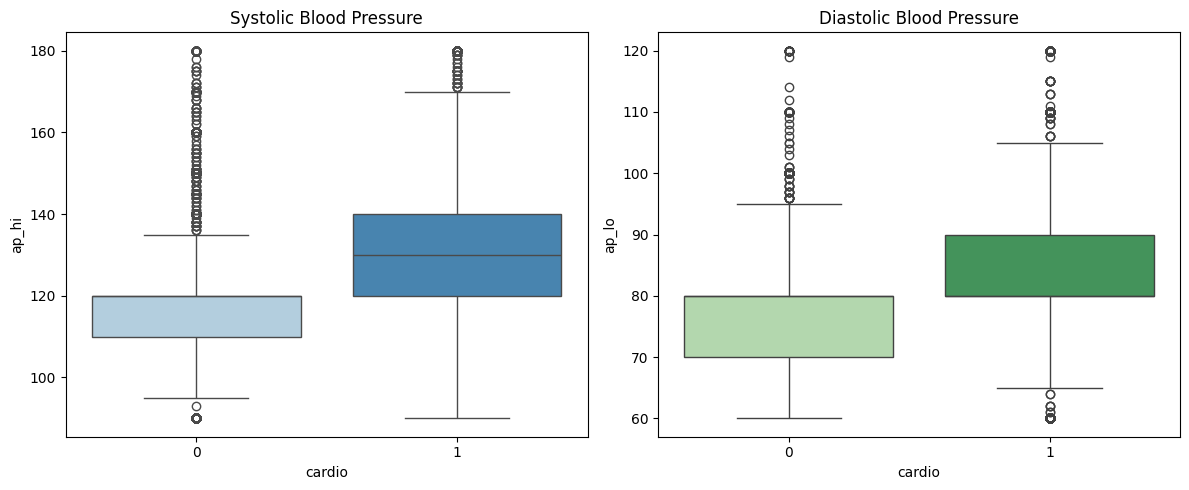

In [32]:
# ==========================================================
# Step 21: Blood Pressure vs Heart Disease
# ==========================================================

fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(
    x="cardio",
    y="ap_hi",
    data=df,
    ax=axes[0],
    palette="Blues"
)

axes[0].set_title("Systolic Blood Pressure")

sns.boxplot(
    x="cardio",
    y="ap_lo",
    data=df,
    ax=axes[1],
    palette="Greens"
)

axes[1].set_title("Diastolic Blood Pressure")

plt.tight_layout()

plt.savefig(
    "../images/blood_pressure_vs_cardio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

Blood pressure measurements differ noticeably between patients with and without cardiovascular disease.

### Key Findings

- Patients diagnosed with heart disease generally have higher systolic and diastolic blood pressure.
- Blood pressure appears to be one of the strongest predictors of cardiovascular disease.

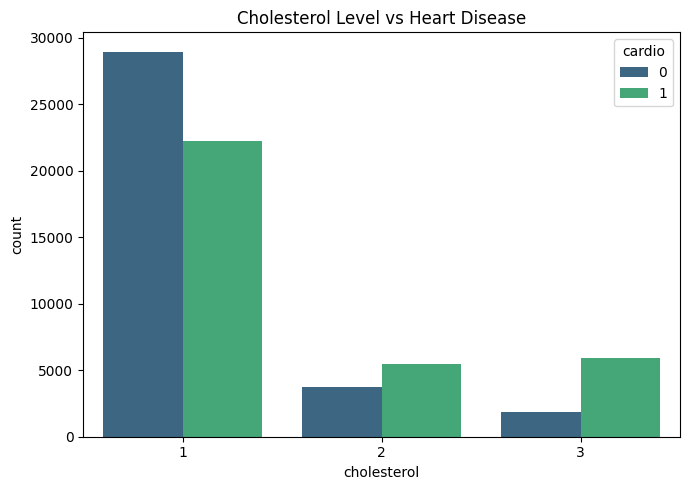

In [33]:
# ==========================================================
# Step 22: Cholesterol vs Heart Disease
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x="cholesterol",
    hue="cardio",
    data=df,
    palette="viridis"
)

plt.title("Cholesterol Level vs Heart Disease")

plt.tight_layout()

plt.savefig(
    "../images/cholesterol_vs_cardio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

Higher cholesterol levels are associated with a greater proportion of patients diagnosed with cardiovascular disease.

### Key Findings

- Patients with elevated cholesterol are more likely to have heart disease.
- Cholesterol is an important clinical risk factor.

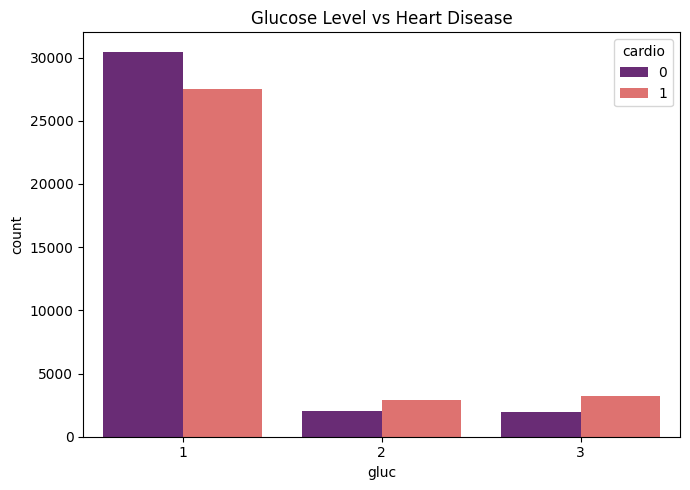

In [34]:
# ==========================================================
# Step 23: Glucose vs Heart Disease
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x="gluc",
    hue="cardio",
    data=df,
    palette="magma"
)

plt.title("Glucose Level vs Heart Disease")

plt.tight_layout()

plt.savefig(
    "../images/glucose_vs_cardio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

Patients with higher glucose levels appear to have an increased occurrence of cardiovascular disease.

### Key Findings

- Higher glucose categories contain a larger proportion of heart disease cases.
- Glucose may contribute to cardiovascular risk prediction.

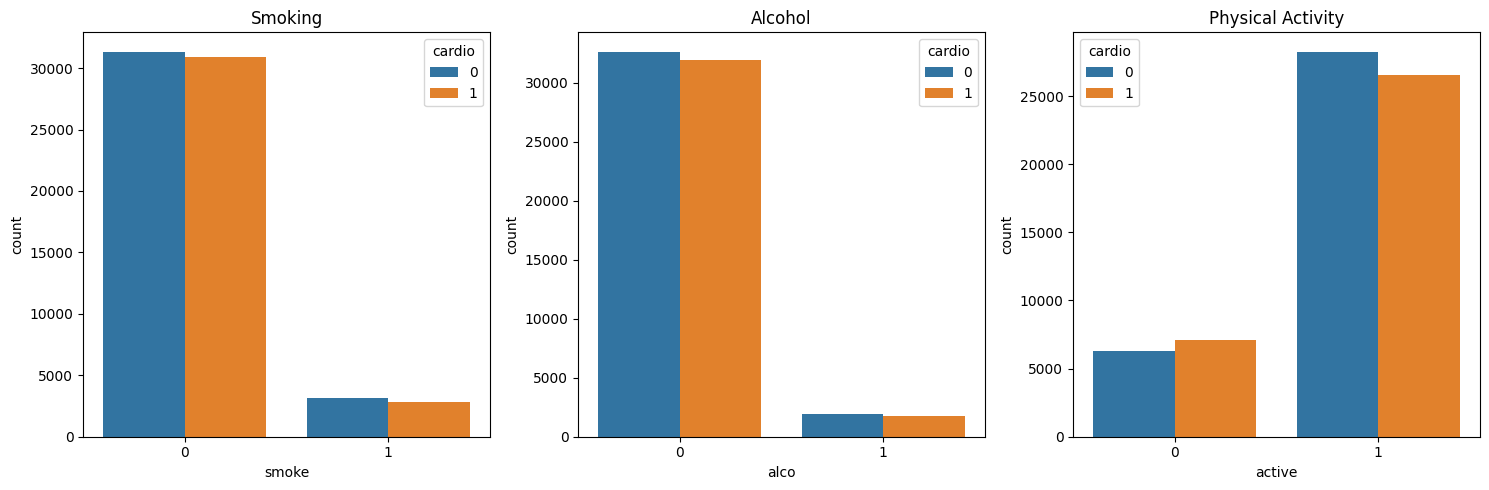

In [35]:
# ==========================================================
# Step 24: Lifestyle Factors vs Heart Disease
# ==========================================================

fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.countplot(
    x="smoke",
    hue="cardio",
    data=df,
    ax=axes[0]
)
axes[0].set_title("Smoking")

sns.countplot(
    x="alco",
    hue="cardio",
    data=df,
    ax=axes[1]
)
axes[1].set_title("Alcohol")

sns.countplot(
    x="active",
    hue="cardio",
    data=df,
    ax=axes[2]
)
axes[2].set_title("Physical Activity")

plt.tight_layout()

plt.savefig(
    "../images/lifestyle_vs_cardio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

Lifestyle-related variables were compared with the target variable to evaluate their association with cardiovascular disease.

### Key Findings

- Smoking and alcohol consumption show weaker individual relationships with cardiovascular disease.
- Physically active individuals generally exhibit a lower proportion of heart disease cases.
- Lifestyle factors may have a stronger combined effect when used together with clinical variables in machine learning models.

# Overall Key Insights

## Key Insights from Exploratory Data Analysis

The exploratory data analysis revealed several important patterns and relationships within the clinical dataset.

### Major Findings

- The dataset is clean, complete, and contains no missing values.
- Duplicate records were removed during the preprocessing phase, resulting in a high-quality dataset.
- The target variable (`cardio`) is reasonably balanced, making it suitable for supervised machine learning.
- Age, blood pressure, cholesterol, BMI, and glucose levels show noticeable relationships with cardiovascular disease.
- Blood pressure (`ap_hi` and `ap_lo`) exhibits the strongest positive correlation with the target variable.
- BMI is strongly correlated with weight, as expected due to its mathematical formulation.
- Lifestyle-related features (smoking, alcohol consumption, and physical activity) have weaker individual correlations with cardiovascular disease but may contribute collectively during model training.
- Several numerical features contain outliers; however, these values are clinically meaningful and have been retained for machine learning.
- No severe multicollinearity was observed among the independent variables, except for expected relationships such as Weight–BMI and Systolic–Diastolic Blood Pressure.

### Overall Interpretation

The exploratory analysis indicates that cardiovascular disease is influenced by multiple clinical and lifestyle factors rather than a single variable. Therefore, machine learning models that consider all relevant features together are expected to provide more accurate predictions than relying on any individual feature.

# Phase 3: Exploratory Data Analysis (EDA) Summary

## Objective

The objective of this phase was to explore the cleaned clinical dataset, understand feature distributions, identify potential anomalies, and analyze the relationships between predictor variables and the target variable before developing machine learning models.

---

## Activities Performed

### Module 1: Dataset Overview

- Examined the structure and dimensions of the dataset.
- Reviewed data types and feature categories.
- Verified data quality.
- Generated descriptive statistics.
- Analyzed the target variable distribution.

### Module 2: Feature Distribution Analysis

- Visualized numerical features using histograms.
- Explored categorical variables using countplots.
- Calculated percentage distributions.
- Created a feature summary table.

### Module 3: Outlier and Correlation Analysis

- Identified outliers using boxplots.
- Quantified outliers using the Interquartile Range (IQR) method.
- Examined relationships among numerical features using a correlation heatmap.
- Evaluated feature correlations with the target variable.

### Module 4: Relationship Between Features and Heart Disease

- Compared age, BMI, and blood pressure across heart disease classes.
- Investigated the association between cholesterol and cardiovascular disease.
- Explored glucose levels and lifestyle-related factors in relation to the target variable.

---

## Key Findings

- The dataset is complete and suitable for machine learning.
- Blood pressure, age, cholesterol, BMI, and glucose are among the most influential clinical features associated with cardiovascular disease.
- Lifestyle-related variables individually show weaker relationships but may improve predictive performance when combined with other features.
- Outliers are present in several numerical variables but were retained because they represent clinically meaningful observations.
- Correlation analysis indicates that no severe multicollinearity exists among the selected predictor variables.

---

## Conclusion

The exploratory data analysis provided a comprehensive understanding of the dataset and highlighted the most significant clinical characteristics associated with cardiovascular disease. The insights gained during this phase support the selection of meaningful features for machine learning and confirm that the dataset is well-prepared for predictive model development.

The next phase will focus on building, training, and evaluating multiple machine learning models to accurately predict cardiovascular disease risk using the processed clinical data.